<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
uploaded = files.upload()

Saving 20021010_easy_ham.tar.bz2 to 20021010_easy_ham.tar (1).bz2


In [ ]:
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only required columns
df = df[['v1', 'v2']]
df.columns = ['Label', 'Email']

df.head()

,Label,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['Label'].value_counts())

Dataset Shape: (5572, 2)

Class Distribution:
Label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

df.head()

,Label,Email
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Email'],
    df['Label'],
    test_size=0.2,
    random_state=42
)

In [ ]:
vectorizer = CountVectorizer(stop_words='english')

X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

In [ ]:
model = MultinomialNB()
model.fit(X_train_counts, y_train)

MultinomialNB()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9838565022421525


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.96      0.92      0.94       150

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



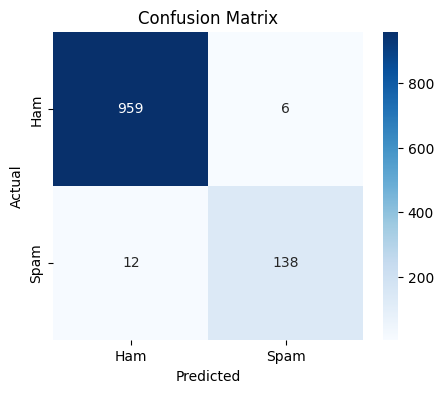

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())

spam_log_prob = model.feature_log_prob_[1]
ham_log_prob = model.feature_log_prob_[0]

difference = spam_log_prob - ham_log_prob

top_spam = np.argsort(difference)[-20:]
top_ham = np.argsort(difference)[:20]

print("Top Spam Words:")
for word in feature_names[top_spam[::-1]]:
    print(word)

print("\nTop Ham Words:")
for word in feature_names[top_ham]:
    print(word)

Top Spam Words:
claim
prize
uk
150p
tone
18
guaranteed
cs
500
1000
150ppm
100
awarded
ringtone
www
entry
tones
000
weekly
collection

Top Ham Words:
lt
gt
lor
da
ì_
later
say
ask
amp
said
doing
morning
really
come
cos
lol
sure
went
nice
feel


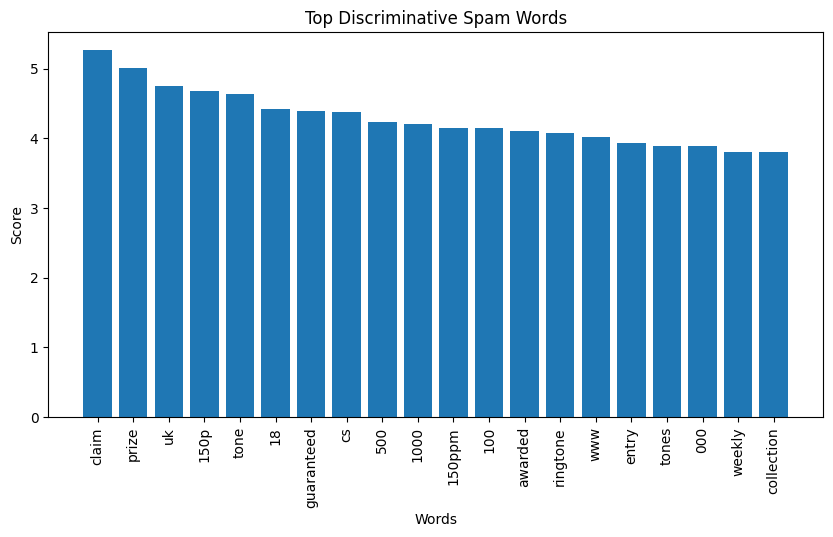

In [ ]:
top_words = feature_names[top_spam[::-1]]
scores = difference[top_spam[::-1]]

plt.figure(figsize=(10,5))
plt.bar(top_words, scores)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Score")
plt.title("Top Discriminative Spam Words")
plt.show()